<a href="https://colab.research.google.com/github/arafatro/IntroToDS/blob/main/Practice%20Materials/Week%203/DS_Practice_Probability_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Data Science
## Week 4 — Probability Intuition via Simulation (Applied)
**Eötvös Loránd University (ELTE) · Faculty of Informatics**

---
**Instructor:** Arafat Md Easin  

> **Tip:** Run each cell with `Shift + Enter`.  
> **Key principle:** If your simulation disagrees with the formula — check the simulation.  
> **NEW — Interactive:** Every figure now has **sliders**. Adjust and re-run the cell to update the plot.


---
## Part 0 — Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── ipywidgets for interactive sliders ────────────────────────────────
import ipywidgets as widgets
from ipywidgets import interact

RNG = np.random.default_rng(seed=42)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi']     = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print('Setup complete — ipywidgets loaded, interactive sliders ready.')


Setup complete — ipywidgets loaded, interactive sliders ready.


---
## Part 1 — The Law of Large Numbers (LLN)

> **Theorem (Weak LLN):**
> $$\hat{p}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{\;p\;} p \quad \text{as } n \to \infty$$


In [12]:
# ── 1.1  Coin flip convergence — INTERACTIVE ──────────────────────────
# N      = total number of flips
# p_true = true probability of heads (%)

def plot_lln(N=10_000, p_true=50):
    p = p_true / 100
    rng = np.random.default_rng(seed=42)
    flips = (rng.uniform(size=N) < p).astype(int)
    cum_mean = np.cumsum(flips) / np.arange(1, N + 1)
    ns = np.arange(1, N + 1)

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(cum_mean, color='steelblue', linewidth=1.2, label='Empirical p̂')
    ax.axhline(p, color='red', linestyle='--', linewidth=1.5, label=f'True p = {p:.2f}')
    ax.fill_between(range(N),
                    p - 1/np.sqrt(ns), p + 1/np.sqrt(ns),
                    alpha=0.12, color='red', label='±1/√n band')
    ax.set_xscale('log')
    ax.set_xlabel('Number of flips (log scale)')
    ax.set_ylabel('Cumulative p̂')
    ax.set_title(f'Law of Large Numbers — Coin Flip Convergence  (N={N:,}, p={p:.2f})')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f'After {N:,} flips:  p̂ = {cum_mean[-1]:.4f}  |  true p = {p:.4f}  |  error = {abs(cum_mean[-1]-p):.4f}')

interact(
    plot_lln,
    N=widgets.IntSlider(value=10_000, min=500, max=100_000, step=500,
                        description='N (flips)', style={'description_width': '120px'},
                        layout=widgets.Layout(width='520px')),
    p_true=widgets.IntSlider(value=50, min=10, max=90, step=5,
                             description='True p (%)', style={'description_width': '120px'},
                             layout=widgets.Layout(width='520px'))
);


interactive(children=(IntSlider(value=10000, description='N (flips)', layout=Layout(width='520px'), max=100000…

In [13]:
# ── 1.2  Rate of convergence — INTERACTIVE ────────────────────────────
# n_repeats = experiments per sample size
# max_n     = largest sample size tested

def plot_convergence(n_repeats=500, max_n=50_000):
    rng = np.random.default_rng(seed=42)
    sample_sizes = sorted(set([10, 50, 100, 500, 1_000, 5_000, 10_000, max_n]))
    true_p = 0.5
    mean_errors = []
    for n in sample_sizes:
        sims = rng.integers(0, 2, size=(n_repeats, n)).mean(axis=1)
        mean_errors.append(np.abs(sims - true_p).mean())
    theoretical = [1 / (2 * np.sqrt(n)) for n in sample_sizes]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(sample_sizes, mean_errors, 'o-', color='steelblue', label='Simulated mean |error|')
    ax.plot(sample_sizes, theoretical, 'r--', label='Theoretical 1/(2√n)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Sample size n (log scale)')
    ax.set_ylabel('Mean absolute error (log scale)')
    ax.set_title(f'Convergence Rate of LLN — Error ≈ O(1/√n)  (repeats={n_repeats:,})')
    ax.legend()
    plt.tight_layout()
    plt.show()

interact(
    plot_convergence,
    n_repeats=widgets.IntSlider(value=500, min=100, max=2000, step=100,
                                description='Repeats', style={'description_width': '110px'},
                                layout=widgets.Layout(width='480px')),
    max_n=widgets.IntSlider(value=50_000, min=5_000, max=200_000, step=5_000,
                            description='Max N', style={'description_width': '110px'},
                            layout=widgets.Layout(width='480px'))
);


interactive(children=(IntSlider(value=500, description='Repeats', layout=Layout(width='480px'), max=2000, min=…

### Exercise 1
A six-sided die is rolled. Simulate P(5 or 6) for N ∈ [10, 100, 1000, 10000, 100000].
```python
# RNG.integers(1, 7, size=N)  → values in {1,2,3,4,5,6}
# true p = 2/6 = 1/3
```


In [14]:
# Your answer here


---
## Part 2 — The Central Limit Theorem (CLT)

> $$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{\;d\;} \mathcal{N}\!\left(\mu,\, \frac{\sigma^2}{n}\right)$$
> This holds **regardless of the shape of the original distribution**.


In [15]:
# ── 2.1  CLT in action — INTERACTIVE ─────────────────────────────────
# n_experiments = sample means drawn per panel
# n_min / n_max  = range of sample sizes (4 evenly-spaced values shown)

def plot_clt(n_experiments=3000, n_min=1, n_max=100):
    rng = np.random.default_rng(seed=42)
    ns = sorted(set([
        n_min,
        max(n_min, int(n_min + (n_max - n_min) * 0.2)),
        max(n_min, int(n_min + (n_max - n_min) * 0.6)),
        n_max
    ]))
    if len(ns) < 2:
        ns = [n_min, n_max]

    distributions = {
        'Uniform(0,1)':     lambda n: rng.uniform(0, 1, size=n),
        'Exponential(λ=1)': lambda n: rng.exponential(1, size=n),
        'Bernoulli(p=0.2)': lambda n: rng.binomial(1, 0.2, size=n),
    }
    fig, axes = plt.subplots(
        len(distributions), len(ns),
        figsize=(4*len(ns), 10), constrained_layout=True
    )
    fig.suptitle(
        f'CLT — Sample Means Converge to Normal'
        f'  (experiments={n_experiments:,}, n ∈ {ns})', fontsize=13)

    for row_i, (dist_name, sampler) in enumerate(distributions.items()):
        for col_j, n in enumerate(ns):
            means = np.array([sampler(n).mean() for _ in range(n_experiments)])
            ax = axes[row_i][col_j] if len(ns) > 1 else axes[row_i]
            ax.hist(means, bins=50, density=True,
                    color='steelblue', edgecolor='white', alpha=0.8)
            mu, sd = means.mean(), means.std()
            if sd > 0:
                xg = np.linspace(means.min(), means.max(), 200)
                ax.plot(xg, stats.norm.pdf(xg, mu, sd), color='red', linewidth=2)
            ax.set_title(f'{dist_name}\nn = {n}', fontsize=9)
            ax.set_xlabel('Sample mean', fontsize=8)
            ax.set_ylabel('Density', fontsize=8)
            ax.tick_params(labelsize=7)
    plt.show()

interact(
    plot_clt,
    n_experiments=widgets.IntSlider(value=3000, min=500, max=10_000, step=500,
                                    description='Experiments', style={'description_width': '120px'},
                                    layout=widgets.Layout(width='500px')),
    n_min=widgets.IntSlider(value=1, min=1, max=50, step=1,
                            description='n  min', style={'description_width': '120px'},
                            layout=widgets.Layout(width='500px')),
    n_max=widgets.IntSlider(value=100, min=5, max=500, step=5,
                            description='n  max', style={'description_width': '120px'},
                            layout=widgets.Layout(width='500px'))
);


interactive(children=(IntSlider(value=3000, description='Experiments', layout=Layout(width='500px'), max=10000…

In [16]:
# ── 2.2  Q-Q plots — INTERACTIVE ──────────────────────────────────────
# n_experiments = sample means per panel
# n_max         = largest sample-size panel shown

def plot_qq(n_experiments=3000, n_max=100):
    rng = np.random.default_rng(seed=42)
    sample_sizes = sorted(set([1, 5, 30, n_max]))
    fig, axes = plt.subplots(1, len(sample_sizes),
                              figsize=(4*len(sample_sizes), 4))
    if len(sample_sizes) == 1:
        axes = [axes]
    fig.suptitle(
        f'Q-Q Plots: Exponential(λ=1) Sample Means'
        f'  (experiments={n_experiments:,})', fontsize=13)
    for ax, n in zip(axes, sample_sizes):
        means = np.array([
            rng.exponential(1, size=n).mean() for _ in range(n_experiments)
        ])
        stats.probplot(means, dist='norm', plot=ax)
        ax.set_title(f'n = {n}', fontsize=11)
        ax.get_lines()[0].set(markersize=2, alpha=0.4)
        ax.get_lines()[1].set(color='red', linewidth=1.5)
    plt.tight_layout()
    plt.show()
    print('The S-curve at n=1 straightens into a diagonal line as n grows → normality.')

interact(
    plot_qq,
    n_experiments=widgets.IntSlider(value=3000, min=500, max=10_000, step=500,
                                    description='Experiments', style={'description_width': '120px'},
                                    layout=widgets.Layout(width='500px')),
    n_max=widgets.IntSlider(value=100, min=10, max=500, step=10,
                            description='n  max panel', style={'description_width': '120px'},
                            layout=widgets.Layout(width='500px'))
);


interactive(children=(IntSlider(value=3000, description='Experiments', layout=Layout(width='500px'), max=10000…

### Exercise 2
Poisson(λ=3) — plot histograms + normal overlay for n ∈ {1, 10, 50}.
```python
# RNG.poisson(lam=3, size=n)
# True mean = λ = 3,  True variance = λ = 3
```


In [17]:
# Your answer here


---
## Part 3 — Classic Probability Paradoxes

---
### 3.1 — The Monty Hall Problem

| Strategy | Intuition | Truth |
|---|---|---|
| Stick  | 50% | **1/3** |
| Switch | 50% | **2/3** |


In [18]:
# ── 3.1  Monty Hall — INTERACTIVE ────────────────────────────────────
# n_games = total games simulated

def plot_monty_hall(n_games=100_000):
    rng = np.random.default_rng(seed=42)
    car    = rng.integers(0, 3, size=n_games)
    player = rng.integers(0, 3, size=n_games)
    p_switch = (player != car).mean()
    p_stick  = (player == car).mean()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(['Stick', 'Switch'], [p_stick, p_switch],
                  color=['coral', 'steelblue'], edgecolor='white', width=0.4)
    ax.plot(['Stick', 'Switch'], [1/3, 2/3], 'kD', markersize=10,
            label='True probability (theory)', zorder=5)
    ax.axhline(0.5, color='grey', linestyle=':', linewidth=1,
               label='50% (naive guess)')
    for bar, p, t in zip(bars, [p_stick, p_switch], [1/3, 2/3]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'Sim: {p:.3f}\nTrue: {t:.3f}', ha='center', fontsize=10)
    ax.set_ylim(0, 0.85)
    ax.set_ylabel('Win probability')
    ax.set_title(f'Monty Hall Problem ({n_games:,} games)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f'Stick: {p_stick:.3f}  |  Switch: {p_switch:.3f}  |  Switching wins {p_switch/p_stick:.2f}× more')

interact(
    plot_monty_hall,
    n_games=widgets.IntSlider(value=100_000, min=1_000, max=500_000, step=1_000,
                              description='Games', style={'description_width': '110px'},
                              layout=widgets.Layout(width='500px'))
);


interactive(children=(IntSlider(value=100000, description='Games', layout=Layout(width='500px'), max=500000, m…

---
### 3.2 — The Birthday Problem

Most guess ~183 people for 50%. The answer is **23**.


In [19]:
# ── 3.2  Birthday Problem — INTERACTIVE ──────────────────────────────
# max_group = largest group size plotted
# n_trials  = simulations per group size

def plot_birthday(max_group=70, n_trials=10_000):
    def exact(n):
        p = 1.0
        for i in range(n): p *= (365 - i) / 365
        return 1 - p

    def sim_prob(n):
        rng = np.random.default_rng(seed=42)
        bdays = rng.integers(1, 366, size=(n_trials, n))
        return np.array([len(set(bdays[i])) < n for i in range(n_trials)]).mean()

    sizes = range(1, max_group + 1)
    ep = [exact(n)    for n in sizes]
    sp = [sim_prob(n) for n in sizes]
    c50 = next((n for n, p in zip(sizes, ep) if p >= 0.50), None)
    c99 = next((n for n, p in zip(sizes, ep) if p >= 0.99), None)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(list(sizes), ep, color='steelblue', linewidth=2.5, label='Analytical')
    ax.plot(list(sizes), sp, color='coral', linestyle='--',
            linewidth=1.5, alpha=0.8, label='Simulation')
    ax.axhline(0.5,  color='green',  linestyle=':', linewidth=1.5)
    ax.axhline(0.99, color='purple', linestyle=':', linewidth=1.5)
    if c50:
        ax.axvline(c50, color='green', linestyle=':', linewidth=1.5,
                   label=f'n={c50} → P≈0.50')
        ax.annotate('50%', xy=(c50, 0.50), xytext=(c50+3, 0.42),
                    fontsize=11, color='green',
                    arrowprops=dict(arrowstyle='->', color='green'))
    if c99 and c99 <= max_group:
        ax.axvline(c99, color='purple', linestyle=':', linewidth=1.5,
                   label=f'n={c99} → P≈0.99')
        ax.annotate('99%', xy=(c99, 0.99), xytext=(max(1, c99-12), 0.90),
                    fontsize=11, color='purple',
                    arrowprops=dict(arrowstyle='->', color='purple'))
    ax.set_xlabel('Number of people')
    ax.set_ylabel('P(at least one shared birthday)')
    ax.set_title(f'Birthday Problem — Simulation vs Analytical  (max n={max_group})')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    if c50: print(f'P(n={c50}): {exact(c50):.4f}')
    if c99: print(f'P(n={c99}): {exact(c99):.4f}')

interact(
    plot_birthday,
    max_group=widgets.IntSlider(value=70, min=10, max=150, step=5,
                                description='Max group', style={'description_width': '120px'},
                                layout=widgets.Layout(width='500px')),
    n_trials=widgets.IntSlider(value=10_000, min=1_000, max=50_000, step=1_000,
                               description='Simulations', style={'description_width': '120px'},
                               layout=widgets.Layout(width='500px'))
);


interactive(children=(IntSlider(value=70, description='Max group', layout=Layout(width='500px'), max=150, min=…

---
### 3.3 — The Gambler's Ruin

**Analytical result:** $P(\text{win}) = k/N$ (fair coin)


In [20]:
# ── 3.3  Gambler's Ruin — INTERACTIVE ────────────────────────────────
# target   = winning target N
# n_games  = games simulated per starting wealth k
# n_paths  = sample trajectories shown on right panel

def plot_gamblers(target=20, n_games=5_000, n_paths=30):
    rng = np.random.default_rng(seed=42)
    starts = list(range(1, target))
    exact  = [k / target for k in starts]

    sim_probs = []
    for k in starts:
        wins = 0
        for _ in range(n_games):
            w, s = k, 0
            while 0 < w < target and s < 10_000:
                w += rng.choice([-1, 1]); s += 1
            if w >= target: wins += 1
        sim_probs.append(wins / n_games)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(starts, exact,     color='steelblue', linewidth=2.5,
                 label=f'Exact: k/{target}')
    axes[0].plot(starts, sim_probs, 'o', color='coral', markersize=5,
                 label='Simulation')
    axes[0].set_xlabel('Starting wealth k')
    axes[0].set_ylabel(f'P(reach N={target})')
    axes[0].set_title(f"Gambler's Ruin — Win Probability (N={target})")
    axes[0].legend()

    k0 = target // 2
    axes[1].set_title(f'Sample Trajectories (start={k0}, target={target})')
    for _ in range(n_paths):
        w, path = k0, [k0]
        while 0 < w < target and len(path) < 600:
            w += rng.choice([-1, 1]); path.append(w)
        axes[1].plot(path,
                     color='steelblue' if path[-1] >= target else 'coral',
                     alpha=0.4, linewidth=0.9)
    axes[1].axhline(target, color='green', linestyle='--', label=f'Win (={target})')
    axes[1].axhline(0,      color='red',   linestyle='--', label='Ruin (=0)')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Wealth')
    axes[1].legend(fontsize=9)

    plt.suptitle(f"Gambler's Ruin (N={target}, fair coin)", fontsize=13)
    plt.tight_layout()
    plt.show()
    sp = sim_probs[k0-1] if k0-1 < len(sim_probs) else float('nan')
    print(f'k={k0}, N={target}  |  P(win) exact={k0/target:.3f}  sim={sp:.3f}')

interact(
    plot_gamblers,
    target  =widgets.IntSlider(value=20, min=5, max=60, step=5,
                               description='Target N', style={'description_width': '110px'},
                               layout=widgets.Layout(width='500px')),
    n_games =widgets.IntSlider(value=5_000, min=500, max=20_000, step=500,
                               description='Games/k',  style={'description_width': '110px'},
                               layout=widgets.Layout(width='500px')),
    n_paths =widgets.IntSlider(value=30, min=10, max=80, step=5,
                               description='Trajectories', style={'description_width': '110px'},
                               layout=widgets.Layout(width='500px'))
);


interactive(children=(IntSlider(value=20, description='Target N', layout=Layout(width='500px'), max=60, min=5,…

### Exercise 3
Unfair coin p=0.45. Analytical: $P(\text{win}|k)=\frac{1-(q/p)^k}{1-(q/p)^N}$
```python
# step = RNG.choice([-1, 1], p=[1-p_win, p_win])
```


In [21]:
# Your answer here


---
## Part 4 — Monte Carlo Estimation


In [22]:
# ── 4.1  Estimating π — INTERACTIVE ──────────────────────────────────
# N      = total darts thrown
# n_show = darts shown in the scatter plot

def plot_mc_pi(N=50_000, n_show=3_000):
    rng = np.random.default_rng(seed=42)
    x = rng.uniform(-1, 1, size=N)
    y = rng.uniform(-1, 1, size=N)
    inside = x**2 + y**2 <= 1
    pi_est = 4 * np.cumsum(inside) / np.arange(1, N + 1)
    n_show = min(n_show, N)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ins = inside[:n_show]
    axes[0].scatter(x[:n_show][ins],  y[:n_show][ins],
                    s=1.5, color='steelblue', alpha=0.6, label='Inside')
    axes[0].scatter(x[:n_show][~ins], y[:n_show][~ins],
                    s=1.5, color='coral',     alpha=0.4, label='Outside')
    theta = np.linspace(0, 2*np.pi, 300)
    axes[0].plot(np.cos(theta), np.sin(theta), 'k-', linewidth=1.5)
    axes[0].set_aspect('equal')
    axes[0].set_title(f'Dart Board ({n_show:,} darts shown)')
    axes[0].legend(fontsize=9, markerscale=5)

    axes[1].plot(pi_est, color='steelblue', linewidth=1, label='π estimate')
    axes[1].axhline(np.pi, color='red', linestyle='--', linewidth=1.5,
                    label=f'True π = {np.pi:.5f}')
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Darts (log scale)')
    axes[1].set_ylabel('Estimated π')
    axes[1].set_title('Convergence of π Estimate')
    axes[1].legend(fontsize=10)

    plt.suptitle(f'Estimating π via Monte Carlo  (N={N:,})', fontsize=13)
    plt.tight_layout()
    plt.show()
    print(f'π ≈ {pi_est[-1]:.5f}  |  error = {abs(pi_est[-1]-np.pi):.5f}')

interact(
    plot_mc_pi,
    N     =widgets.IntSlider(value=50_000, min=1_000, max=300_000, step=1_000,
                             description='N (darts)', style={'description_width': '120px'},
                             layout=widgets.Layout(width='520px')),
    n_show=widgets.IntSlider(value=3_000,  min=500,   max=20_000,  step=500,
                             description='Shown in plot', style={'description_width': '120px'},
                             layout=widgets.Layout(width='520px'))
);


interactive(children=(IntSlider(value=50000, description='N (darts)', layout=Layout(width='520px'), max=300000…

In [23]:
# ── 4.2  Monte Carlo Integration — INTERACTIVE ───────────────────────
# N = number of random sample points

def plot_mc_integration(N=100_000):
    rng = np.random.default_rng(seed=42)
    def mc(f, a, b):
        xs = rng.uniform(a, b, size=N)
        return (b - a) * f(xs).mean()
    tests = [
        ('∫₀¹ x² dx',             lambda x: x**2,              0,      1,      1/3),
        ('∫₀¹ √(1-x²) dx = π/4', lambda x: np.sqrt(1 - x**2), 0,      1,      np.pi/4),
        ('∫₀^π sin(x) dx',        lambda x: np.sin(x),          0,      np.pi,  2.0),
        ('∫₁^e 1/x dx = 1',       lambda x: 1/x,                1,      np.e,   1.0),
    ]
    print(f'Monte Carlo Integration  (N={N:,})')
    print(f'{"Integral":<32} {"Estimate":>10} {"True":>10} {"Error":>10}')
    print('-' * 66)
    for name, f, a, b, tv in tests:
        e = mc(f, a, b)
        print(f'{name:<32} {e:>10.5f} {tv:>10.5f} {abs(e-tv):>10.5f}')

interact(
    plot_mc_integration,
    N=widgets.IntSlider(value=100_000, min=1_000, max=1_000_000, step=10_000,
                        description='N (samples)', style={'description_width': '120px'},
                        layout=widgets.Layout(width='520px'))
);


interactive(children=(IntSlider(value=100000, description='N (samples)', layout=Layout(width='520px'), max=100…

### Exercise 4
$$\int_0^1 e^{-x^2}\,dx \approx 0.74682$$
Estimate for N ∈ {1000, 10000, 100000, 1000000}. Is error ∼ O(1/√N)?


In [24]:
# Your answer here


---
## Part 5 — Bootstrap Resampling


In [25]:
iris   = sns.load_dataset('iris')
sample = iris.loc[iris['species'] == 'setosa', 'sepal_length'].values
print(f'n={len(sample)}, mean={sample.mean():.4f}, median={np.median(sample):.4f}')


n=50, mean=5.0060, median=5.0000


In [26]:
# ── 5.2 / 5.3  Bootstrap CI — INTERACTIVE ────────────────────────────
# B      = number of bootstrap resamples
# ci_pct = confidence level (%)

def plot_bootstrap(B=10_000, ci_pct=95):
    rng   = np.random.default_rng(seed=42)
    alpha = (1 - ci_pct/100) / 2
    n     = len(sample)

    boot_means   = np.array([
        rng.choice(sample, size=n, replace=True).mean() for _ in range(B)])
    boot_medians = np.array([
        np.median(rng.choice(sample, size=n, replace=True)) for _ in range(B)])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, bd, name, obs in [
        (axes[0], boot_means,   'Mean',   sample.mean()),
        (axes[1], boot_medians, 'Median', np.median(sample)),
    ]:
        lo, hi = np.quantile(bd, alpha), np.quantile(bd, 1 - alpha)
        ax.hist(bd, bins=60, density=True, color='steelblue',
                edgecolor='white', alpha=0.85)
        ax.axvline(obs, color='red',   linestyle='--', linewidth=2,
                   label=f'Observed {name}: {obs:.3f}')
        ax.axvline(lo,  color='green', linestyle=':',  linewidth=1.8,
                   label=f'{ci_pct}% CI: [{lo:.3f}, {hi:.3f}]')
        ax.axvline(hi,  color='green', linestyle=':',  linewidth=1.8)
        ax.fill_betweenx([0, ax.get_ylim()[1] or 10], lo, hi,
                          alpha=0.1, color='green')
        ax.set_xlabel(f'Bootstrap {name}')
        ax.set_ylabel('Density')
        ax.set_title(f'Bootstrap Distribution of {name}\n(B={B:,}, {ci_pct}% CI)')
        ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    lom = np.quantile(boot_means,   alpha); him = np.quantile(boot_means,   1-alpha)
    lod = np.quantile(boot_medians, alpha); hid = np.quantile(boot_medians, 1-alpha)
    print(f'{ci_pct}% CI Mean:   [{lom:.4f}, {him:.4f}]')
    print(f'{ci_pct}% CI Median: [{lod:.4f}, {hid:.4f}]')

interact(
    plot_bootstrap,
    B     =widgets.IntSlider(value=10_000, min=500,  max=50_000, step=500,
                             description='B (resamples)', style={'description_width': '130px'},
                             layout=widgets.Layout(width='520px')),
    ci_pct=widgets.IntSlider(value=95,     min=80,   max=99,     step=1,
                             description='CI level (%)',  style={'description_width': '130px'},
                             layout=widgets.Layout(width='520px'))
);


interactive(children=(IntSlider(value=10000, description='B (resamples)', layout=Layout(width='520px'), max=50…

In [27]:
# ── 5.4  CI width vs sample size — INTERACTIVE ───────────────────────
# B     = bootstrap resamples
# max_n = largest sample size shown

def plot_ci_width(B=5_000, max_n=100):
    rng = np.random.default_rng(seed=42)
    pop = iris['sepal_length'].values
    ns  = sorted(set(n for n in [5, 10, 20, 30, 50, 75, max_n] if n <= len(pop)))
    widths = []
    for n in ns:
        sub = rng.choice(pop, size=n, replace=False)
        bm  = np.array([rng.choice(sub, size=n, replace=True).mean()
                         for _ in range(B)])
        widths.append(np.quantile(bm, 0.975) - np.quantile(bm, 0.025))
    theoretical = [4 / np.sqrt(n) * pop.std() for n in ns]

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ns, widths,      'o-',  color='steelblue', linewidth=2, markersize=8)
    ax.plot(ns, theoretical, 'r--', linewidth=1.5, label='Theoretical ∝ 1/√n')
    ax.set_xlabel('Sample size n')
    ax.set_ylabel('95% CI width')
    ax.set_title(f'Bootstrap CI Width vs Sample Size  (B={B:,}, max n={max_n})')
    ax.legend()
    plt.tight_layout()
    plt.show()

interact(
    plot_ci_width,
    B    =widgets.IntSlider(value=5_000, min=500,  max=20_000, step=500,
                            description='B (resamples)', style={'description_width': '130px'},
                            layout=widgets.Layout(width='520px')),
    max_n=widgets.IntSlider(value=100,   min=30,   max=150,    step=5,
                            description='Max n', style={'description_width': '130px'},
                            layout=widgets.Layout(width='520px'))
);


interactive(children=(IntSlider(value=5000, description='B (resamples)', layout=Layout(width='520px'), max=200…

### Exercise 5
Bootstrap 95% CI for Pearson correlation between `petal_length` and `petal_width`.
```python
# indices = RNG.integers(0, n, size=n)
# corr = np.corrcoef(petal_length[indices], petal_width[indices])[0, 1]
```


In [28]:
# Your answer here


---
## Part 6 — Full Simulation Workflow

**Scenario:** Historical CTR = 5%. New data: 32 clicks / 500 impressions. Did it increase?


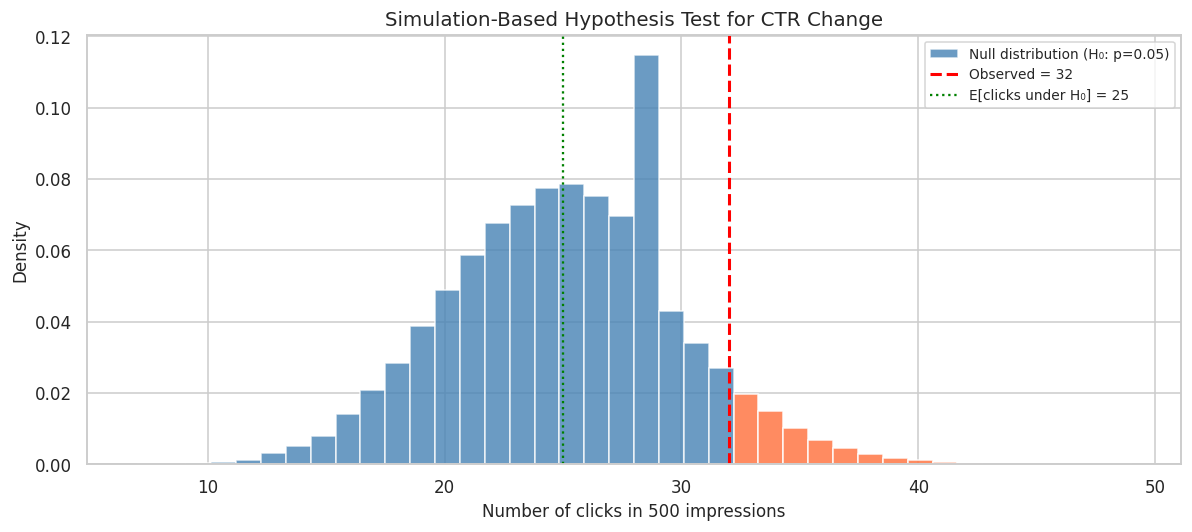

Observed clicks:     32  (6.4% CTR)
Expected under H₀:   25  (5.0% CTR)

p-value (simulation):  0.0949
p-value (exact test):  0.0945

→ Fail to reject H₀: insufficient evidence of a change


In [33]:
# ── 6.1  Simulate the null distribution ──────────────────────────────
# Null hypothesis H₀: CTR = 0.05 (no change)
# Question: how often does H₀ produce 32 or more clicks in 500 trials?

p_null    = 0.05
n_trials  = 500
observed  = 32
n_sims    = 100_000

null_clicks = RNG.binomial(n=n_trials, p=p_null, size=n_sims)
p_value_sim = (null_clicks >= observed).mean()

# Analytical p-value using exact binomial test
p_value_exact = stats.binom.sf(observed - 1, n_trials, p_null)

fig, ax = plt.subplots(figsize=(11, 5))

# Null distribution
counts, bins, patches = ax.hist(null_clicks, bins=40, density=True,
                                color="steelblue", edgecolor="white", alpha=0.8,
                                label="Null distribution (H₀: p=0.05)")

# Colour the rejection region
for patch, left in zip(patches, bins[:-1]):
    if left >= observed:
        patch.set_facecolor("coral")
        patch.set_alpha(0.9)

ax.axvline(observed, color="red", linestyle="--", linewidth=2,
           label=f"Observed = {observed}")
ax.axvline(n_trials * p_null, color="green", linestyle=":", linewidth=1.5,
           label=f"E[clicks under H₀] = {n_trials*p_null:.0f}")

ax.set_xlabel("Number of clicks in 500 impressions")
ax.set_ylabel("Density")
ax.set_title("Simulation-Based Hypothesis Test for CTR Change")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Observed clicks:     {observed}  ({observed/n_trials:.1%} CTR)")
print(f"Expected under H₀:   {n_trials * p_null:.0f}  ({p_null:.1%} CTR)")
print(f"\np-value (simulation):  {p_value_sim:.4f}")
print(f"p-value (exact test):  {p_value_exact:.4f}")
print(f"\n→ {'Reject H₀: CTR has significantly increased (α=0.05)' if p_value_sim < 0.05 else 'Fail to reject H₀: insufficient evidence of a change'}")


In [34]:
# ── 6.2  Bootstrap CTR — INTERACTIVE ─────────────────────────────────
# observed  = clicks seen
# n_trials  = total impressions
# B         = bootstrap resamples

def plot_bootstrap_ctr(observed=32, n_trials=500, B=10_000):
    rng  = np.random.default_rng(seed=42)
    observed = min(observed, n_trials)
    data = np.array([1]*observed + [0]*(n_trials - observed))
    boot = np.array([
        rng.choice(data, size=n_trials, replace=True).mean() for _ in range(B)])
    lo, hi  = np.quantile(boot, 0.025), np.quantile(boot, 0.975)
    obs_ctr = observed / n_trials

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(boot, bins=50, density=True, color='steelblue',
            edgecolor='white', alpha=0.85)
    ax.axvline(obs_ctr, color='red',    linestyle='--', linewidth=2,
               label=f'Observed CTR = {obs_ctr:.3f}')
    ax.axvline(0.05,    color='purple', linestyle=':',  linewidth=2,
               label='Null CTR = 0.05')
    ax.axvline(lo,      color='green',  linestyle=':',  linewidth=1.8,
               label=f'95% CI [{lo:.3f}, {hi:.3f}]')
    ax.axvline(hi,      color='green',  linestyle=':',  linewidth=1.8)
    ax.fill_betweenx([0, 25], lo, hi, alpha=0.12, color='green')
    ax.set_xlabel('CTR')
    ax.set_ylabel('Density')
    ax.set_title(f'Bootstrap CI for CTR  ({observed}/{n_trials}, B={B:,})')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    outside = 'OUTSIDE' if 0.05 < lo else 'inside'
    print(f'95% CI: [{lo:.4f}, {hi:.4f}]  — null 0.05 is {outside} the CI')

interact(
    plot_bootstrap_ctr,
    observed =widgets.IntSlider(value=32,      min=0,     max=200,    step=1,
                                description='Obs. clicks',   style={'description_width': '130px'},
                                layout=widgets.Layout(width='520px')),
    n_trials =widgets.IntSlider(value=500,     min=50,    max=5000,   step=50,
                                description='Impressions',   style={'description_width': '130px'},
                                layout=widgets.Layout(width='520px')),
    B        =widgets.IntSlider(value=10_000,  min=1_000, max=50_000, step=1_000,
                                description='B (resamples)', style={'description_width': '130px'},
                                layout=widgets.Layout(width='520px'))
);


interactive(children=(IntSlider(value=32, description='Obs. clicks', layout=Layout(width='520px'), max=200, st…

---
## Part 7 — Common Distributions via Simulation


In [35]:
# ── 7.1  Distribution gallery — INTERACTIVE ──────────────────────────
# N    = samples per distribution
# bins = histogram bins

def plot_gallery(N=20_000, bins=60):
    rng = np.random.default_rng(seed=42)
    dists = [
        ('Normal(μ=0, σ=1)',     rng.normal(0, 1, N),         'steelblue'),
        ('Uniform(0, 1)',         rng.uniform(0, 1, N),         'coral'),
        ('Exponential(λ=1)',      rng.exponential(1, N),        'seagreen'),
        ('Binomial(n=20, p=0.4)', rng.binomial(20, 0.4, N),     'mediumpurple'),
        ('Poisson(λ=4)',          rng.poisson(4, N),            'goldenrod'),
        ('Beta(α=2, β=5)',        rng.beta(2, 5, N),            'salmon'),
        ('Gamma(k=3, θ=2)',       rng.gamma(3, 2, N),           'teal'),
        ('Student t (df=3)',      rng.standard_t(3, N),         'orchid'),
    ]
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(f'Gallery of Common Probability Distributions  (N={N:,})', fontsize=14)
    for ax, (name, data, color) in zip(axes.flat, dists):
        ax.hist(data, bins=bins, density=True, color=color,
                edgecolor='white', alpha=0.85)
        ax.axvline(data.mean(),     color='red',  linestyle='--', linewidth=1.5,
                   label=f'mean={data.mean():.2f}')
        ax.axvline(np.median(data), color='blue', linestyle=':',  linewidth=1.5,
                   label=f'med={np.median(data):.2f}')
        ax.set_title(name, fontsize=10)
        ax.legend(fontsize=7)
        ax.set_ylabel('Density', fontsize=8)
        ax.tick_params(labelsize=7)
    plt.tight_layout()
    plt.show()

interact(
    plot_gallery,
    N   =widgets.IntSlider(value=20_000, min=1_000,  max=100_000, step=1_000,
                           description='N (samples)', style={'description_width': '120px'},
                           layout=widgets.Layout(width='520px')),
    bins=widgets.IntSlider(value=60,     min=10,     max=150,     step=5,
                           description='Bins', style={'description_width': '120px'},
                           layout=widgets.Layout(width='520px'))
);


interactive(children=(IntSlider(value=20000, description='N (samples)', layout=Layout(width='520px'), max=1000…

### Exercise 6 — Inspection Paradox
Buses arrive every ~10 min. Naive wait = 5 min. **True wait = 10 min.**
```python
# bus_times = np.cumsum(RNG.exponential(10, size=100_000))
# np.searchsorted(bus_times, passenger_time) → index of next bus
```


In [32]:
# Your answer here


---
## Summary

| Concept | Key Takeaway |
|---|---|
| **Law of Large Numbers** | Empirical frequency → true probability; error ≈ O(1/√n) |
| **Central Limit Theorem** | Sample means are normal regardless of parent; kicks in ~n=30 |
| **Monty Hall** | Switching wins 2/3 — simulation makes this undeniable |
| **Birthday Problem** | Only 23 people for 50% chance of shared birthday |
| **Gambler's Ruin** | Even a small house edge drastically reduces win probability |
| **Monte Carlo Integration** | Estimate any integral by averaging function values at random points |
| **Bootstrap** | Re-sample with replacement for a CI on *any* statistic |
| **Simulation testing** | Simulate the null distribution to compute p-values empirically |
| **Distribution gallery** | Mean ≠ median when skewed |

---
*Eötvös Loránd University (ELTE) · Faculty of Informatics · Introduction to Data Science*
